# External Validation of the Extra Trees Model

This notebook performs external validation of the developed Extra Trees (ET) model using an independent CYP3A4 dataset collected from Indonesian herbal compounds.

The workflow includes:

1. Data loading
2. Structure curation
3. Activity labeling
4. Feature generation
5. Chemical space comparison (UMAP)
6. External validation
7. Model performance evaluation
8. SHAP interpretation

In [1]:
# ============================================================
# External Validation of Extra Trees Model for CYP3A4
# ============================================================

# Basic libraries
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import SaltRemover

# Machine Learning
import joblib

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Dimensionality reduction
import umap.umap_ as umap

# SHAP
import shap

# Display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("="*60)
print("External Validation Notebook Initialized")
print("="*60)

External Validation Notebook Initialized


## Load External Validation Dataset

Load the raw external validation dataset and inspect its basic information before structure curation.

In [2]:
# Load dataset
df_ext = pd.read_csv("external_validation_raw.csv")

print("=" * 60)
print("External Validation Dataset")
print("=" * 60)

print(f"Number of compounds : {len(df_ext)}")
print(f"Number of columns   : {df_ext.shape[1]}")

display(df_ext.head())

External Validation Dataset
Number of compounds : 35
Number of columns   : 9


,CID,SMILES,InChIKey,PubChem_Status,Senyawa,IC50,Unit,Assay_ID,Assay_Description
0,969516,COC1=C(C=CC(=C1)/C=C/C(=O)CC(=O)/C=C/C2=CC(=C(C=C2)O)OC)O,VFLDPWHFBUODDF-FCXRPNKRSA-N,FOUND,Curcumin,16300.0,nM,CHEMBL999389,Inhibition of human recombinant CYP3A4
1,5280343,C1=CC(=C(C=C1C2=C(C(=O)C3=C(C=C(C=C3O2)O)O)O)O)O,REFJWTPEDVJJIY-UHFFFAOYSA-N,FOUND,quercetin,2110.0,nM,CHEMBL3534776,Inhibition of CYP3A4 in human liver microsomes using midazolam as substrate after 8 mins by LC-MS/MS analysis
2,5280805,C[C@H]1[C@@H]([C@H]([C@H]([C@@H](O1)OC[C@@H]2[C@H]([C@@H]([C@H]([C@@H](O2)OC3=C(OC4=CC(=CC(=C4C3=O)O)O)C5=CC(=C(C=C5)O)O)O)O)O)O)O)O,IKGXIBQEEMLURG-NVPNHPEKSA-N,FOUND,Rutin,80000.0,nM,CHEMBL972070,Inhibition of CYP3A4
3,5280343,C1=CC(=C(C=C1C2=C(C(=O)C3=C(C=C(C=C3O2)O)O)O)O)O,REFJWTPEDVJJIY-UHFFFAOYSA-N,FOUND,Quercetin,2110.0,nM,CHEMBL3534776,Inhibition of CYP3A4 in human liver microsomes using midazolam as substrate after 8 mins by LC-MS/MS analysis
4,222284,CC[C@H](CC[C@@H](C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3[C@H]2CC=C4[C@@]3(CC[C@@H](C4)O)C)C)C(C)C,KZJWDPNRJALLNS-VJSFXXLFSA-N,FOUND,beta-sitosterol,100000.0,nM,CHEMBL1000805,Inhibition of human CYP3A4 by radiometric assay


In [3]:
# Dataset information
df_ext.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CID                35 non-null     int64  
 1   SMILES             35 non-null     object 
 2   InChIKey           35 non-null     object 
 3   PubChem_Status     35 non-null     object 
 4   Senyawa            35 non-null     object 
 5   IC50               35 non-null     float64
 6   Unit               35 non-null     object 
 7   Assay_ID           35 non-null     object 
 8   Assay_Description  35 non-null     object 
dtypes: float64(1), int64(1), object(7)
memory usage: 2.6+ KB


In [4]:
# Missing values
df_ext.isnull().sum()

CID                  0
SMILES               0
InChIKey             0
PubChem_Status       0
Senyawa              0
IC50                 0
Unit                 0
Assay_ID             0
Assay_Description    0
dtype: int64

In [5]:
# Duplicate rows
print(f"Duplicate rows : {df_ext.duplicated().sum()}")

Duplicate rows : 0


In [6]:
# Summary statistics
df_ext.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CID,35.0,NaN,NaN,NaN,2396161.314286,2581098.51731,190.0,160521.0,442793.0,5281699.5,5481663.0
SMILES,35,25,CC[C@H](CC[C@@H](C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3[C@H]2CC=C4[C@@]3(CC[C@@H](C4)O)C)C)C(C)C,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InChIKey,35,25,KZJWDPNRJALLNS-VJSFXXLFSA-N,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PubChem_Status,35,1,FOUND,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Senyawa,35,35,Curcumin,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IC50,35.0,NaN,NaN,NaN,42853.142857,44914.953017,600.0,7600.0,16300.0,100000.0,142400.0
Unit,35,1,nM,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Assay_ID,35,18,CHEMBL1000805,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Assay_Description,35,17,Inhibition of human CYP3A4 by radiometric assay,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Structure Curation

The external validation dataset was curated using the same preprocessing workflow applied to the training dataset.

The curation procedure included:

1. Removal of invalid SMILES
2. Salt removal
3. Removal of inorganic molecules
4. Molecular standardization
5. Canonical SMILES generation
6. Removal of duplicate structures

In [7]:
# Structure curation summary

curation_summary = []

def add_summary(step, before, after):
    curation_summary.append({
        "Step": step,
        "Before": before,
        "After": after,
        "Removed": before-after
    })

In [8]:
print("="*60)
print("Step 1 - Remove Invalid SMILES")
print("="*60)

before = len(df_ext)

# valid molecule
df_ext["Mol"] = df_ext["SMILES"].apply(Chem.MolFromSmiles)

# remove invalid
df_ext = df_ext[df_ext["Mol"].notnull()].copy()

after = len(df_ext)

add_summary(
    "Remove invalid SMILES",
    before,
    after
)

print(f"Compounds before : {before}")
print(f"Compounds after  : {after}")
print(f"Removed          : {before-after}")

Step 1 - Remove Invalid SMILES
Compounds before : 35
Compounds after  : 35
Removed          : 0


In [9]:
df_ext.head()

,CID,SMILES,InChIKey,PubChem_Status,Senyawa,IC50,Unit,Assay_ID,Assay_Description,Mol
0,969516,COC1=C(C=CC(=C1)/C=C/C(=O)CC(=O)/C=C/C2=CC(=C(C=C2)O)OC)O,VFLDPWHFBUODDF-FCXRPNKRSA-N,FOUND,Curcumin,16300.0,nM,CHEMBL999389,Inhibition of human recombinant CYP3A4,<rdkit.Chem.rdchem.Mol object at 0x0000019303AC2F10>
1,5280343,C1=CC(=C(C=C1C2=C(C(=O)C3=C(C=C(C=C3O2)O)O)O)O)O,REFJWTPEDVJJIY-UHFFFAOYSA-N,FOUND,quercetin,2110.0,nM,CHEMBL3534776,Inhibition of CYP3A4 in human liver microsomes using midazolam as substrate after 8 mins by LC-MS/MS analysis,<rdkit.Chem.rdchem.Mol object at 0x0000019303AC3ED0>
2,5280805,C[C@H]1[C@@H]([C@H]([C@H]([C@@H](O1)OC[C@@H]2[C@H]([C@@H]([C@H]([C@@H](O2)OC3=C(OC4=CC(=CC(=C4C3=O)O)O)C5=CC(=C(C=C5)O)O)O)O)O)O)O)O,IKGXIBQEEMLURG-NVPNHPEKSA-N,FOUND,Rutin,80000.0,nM,CHEMBL972070,Inhibition of CYP3A4,<rdkit.Chem.rdchem.Mol object at 0x0000019303AC1C40>
3,5280343,C1=CC(=C(C=C1C2=C(C(=O)C3=C(C=C(C=C3O2)O)O)O)O)O,REFJWTPEDVJJIY-UHFFFAOYSA-N,FOUND,Quercetin,2110.0,nM,CHEMBL3534776,Inhibition of CYP3A4 in human liver microsomes using midazolam as substrate after 8 mins by LC-MS/MS analysis,<rdkit.Chem.rdchem.Mol object at 0x0000019303AC1F50>
4,222284,CC[C@H](CC[C@@H](C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3[C@H]2CC=C4[C@@]3(CC[C@@H](C4)O)C)C)C(C)C,KZJWDPNRJALLNS-VJSFXXLFSA-N,FOUND,beta-sitosterol,100000.0,nM,CHEMBL1000805,Inhibition of human CYP3A4 by radiometric assay,<rdkit.Chem.rdchem.Mol object at 0x0000019303AC2420>


In [10]:
pd.DataFrame(curation_summary)

,Step,Before,After,Removed
0,Remove invalid SMILES,35,35,0


In [11]:
print("="*60)
print("Step 2 - Salt Removal")
print("="*60)

before = len(df_ext)

remover = SaltRemover.SaltRemover()

def remove_salt(mol):
    if mol is None:
        return None
    try:
        mol = remover.StripMol(mol, dontRemoveEverything=True)
        return mol
    except:
        return None

df_ext["Mol"] = df_ext["Mol"].apply(remove_salt)

after = df_ext["Mol"].notnull().sum()

add_summary(
    "Remove salts",
    before,
    after
)

print(f"Compounds before : {before}")
print(f"Compounds after  : {after}")
print(f"Removed          : {before-after}")

Step 2 - Salt Removal
Compounds before : 35
Compounds after  : 35
Removed          : 0


In [12]:
df_ext["SMILES"] = df_ext["Mol"].apply(Chem.MolToSmiles)

In [13]:
pd.DataFrame(curation_summary)

,Step,Before,After,Removed
0,Remove invalid SMILES,35,35,0
1,Remove salts,35,35,0


In [14]:
print("="*60)
print("Step 3 - Remove Inorganic Molecules")
print("="*60)

before = len(df_ext)

def is_organic(mol):
    """
    Keep molecules containing at least one carbon atom.
    """
    if mol is None:
        return False

    return any(atom.GetAtomicNum() == 6 for atom in mol.GetAtoms())

df_ext = df_ext[df_ext["Mol"].apply(is_organic)].copy()

after = len(df_ext)

add_summary(
    "Remove inorganic molecules",
    before,
    after
)

print(f"Compounds before : {before}")
print(f"Compounds after  : {after}")
print(f"Removed          : {before-after}")

Step 3 - Remove Inorganic Molecules
Compounds before : 35
Compounds after  : 35
Removed          : 0


In [15]:
pd.DataFrame(curation_summary)

,Step,Before,After,Removed
0,Remove invalid SMILES,35,35,0
1,Remove salts,35,35,0
2,Remove inorganic molecules,35,35,0


In [16]:
print("="*60)
print("Step 4 - Molecule Standardization")
print("="*60)

from rdkit.Chem.MolStandardize import rdMolStandardize

before = len(df_ext)

# Standardize molecules
df_ext["Mol_Standardized"] = df_ext["Mol"].apply(
    lambda mol: rdMolStandardize.Cleanup(mol)
)

# Preview standardized SMILES
df_ext["SMILES_Standardized"] = df_ext["Mol_Standardized"].apply(
    lambda mol: Chem.MolToSmiles(mol)
)

after = len(df_ext)

add_summary(
    "Molecule standardization",
    before,
    after
)

print(f"Compounds before : {before}")
print(f"Compounds after  : {after}")
print(f"Removed          : {before-after}")

df_ext[
    ["SMILES", "SMILES_Standardized"]
].head(10)

Step 4 - Molecule Standardization
Compounds before : 35
Compounds after  : 35
Removed          : 0


[06:25:11] Initializing MetalDisconnector
[06:25:11] Running MetalDisconnector
[06:25:11] Initializing Normalizer
[06:25:11] Running Normalizer
[06:25:11] Initializing MetalDisconnector
[06:25:11] Running MetalDisconnector
[06:25:11] Initializing Normalizer
[06:25:11] Running Normalizer
[06:25:11] Initializing MetalDisconnector
[06:25:11] Running MetalDisconnector
[06:25:11] Initializing Normalizer
[06:25:11] Running Normalizer
[06:25:11] Initializing MetalDisconnector
[06:25:11] Running MetalDisconnector
[06:25:11] Initializing Normalizer
[06:25:11] Running Normalizer
[06:25:11] Initializing MetalDisconnector
[06:25:11] Running MetalDisconnector
[06:25:11] Initializing Normalizer
[06:25:11] Running Normalizer
[06:25:11] Initializing MetalDisconnector
[06:25:11] Running MetalDisconnector
[06:25:11] Initializing Normalizer
[06:25:11] Running Normalizer
[06:25:11] Initializing MetalDisconnector
[06:25:11] Running MetalDisconnector
[06:25:11] Initializing Normalizer
[06:25:11] Running Nor

,SMILES,SMILES_Standardized
0,COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O,COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O
1,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12
2,C[C@@H]1O[C@@H](OC[C@H]2O[C@@H](Oc3c(-c4ccc(O)c(O)c4)oc4cc(O)cc(O)c4c3=O)[C@H](O)[C@@H](O)[C@@H]2O)[C@H](O)[C@H](O)[C@H]1O,C[C@@H]1O[C@@H](OC[C@H]2O[C@@H](Oc3c(-c4ccc(O)c(O)c4)oc4cc(O)cc(O)c4c3=O)[C@H](O)[C@@H](O)[C@@H]2O)[C@H](O)[C@H](O)[C@H]1O
3,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12
4,CC[C@H](CC[C@@H](C)[C@H]1CC[C@H]2[C@@H]3CC=C4C[C@@H](O)CC[C@]4(C)[C@H]3CC[C@]12C)C(C)C,CC[C@H](CC[C@@H](C)[C@H]1CC[C@H]2[C@@H]3CC=C4C[C@@H](O)CC[C@]4(C)[C@H]3CC[C@]12C)C(C)C
5,C/C1=C\CC(C)(C)/C=C/C(=O)/C(C)=C/CC1,C/C1=C\CC(C)(C)/C=C/C(=O)/C(C)=C/CC1
6,CCCCC/C=C/C(=O)CCc1ccc(O)c(OC)c1,CCCCC/C=C/C(=O)CCc1ccc(O)c(OC)c1
7,CC[C@H](CC[C@@H](C)[C@H]1CC[C@H]2[C@@H]3CC=C4C[C@@H](O)CC[C@]4(C)[C@H]3CC[C@]12C)C(C)C,CC[C@H](CC[C@@H](C)[C@H]1CC[C@H]2[C@@H]3CC=C4C[C@@H](O)CC[C@]4(C)[C@H]3CC[C@]12C)C(C)C
8,CC(=O)Nc1ccc(O)cc1,CC(=O)Nc1ccc(O)cc1
9,CC(C)=CCC/C(C)=C/COc1c2ccoc2cc2oc(=O)ccc12,CC(C)=CCC/C(C)=C/COc1c2ccoc2cc2oc(=O)ccc12


In [17]:
pd.DataFrame(curation_summary)

,Step,Before,After,Removed
0,Remove invalid SMILES,35,35,0
1,Remove salts,35,35,0
2,Remove inorganic molecules,35,35,0
3,Molecule standardization,35,35,0


In [18]:
print("="*60)
print("Step 5 - Canonical SMILES Generation")
print("="*60)

before = len(df_ext)

# Generate canonical SMILES
df_ext["SMILES_Canonical"] = df_ext["Mol_Standardized"].apply(
    lambda mol: Chem.MolToSmiles(mol, canonical=True)
)

after = len(df_ext)

add_summary(
    "Canonical SMILES generation",
    before,
    after
)

print(f"Compounds before : {before}")
print(f"Compounds after  : {after}")
print(f"Removed          : {before-after}")

df_ext[
    ["SMILES_Standardized", "SMILES_Canonical"]
].head(10)

Step 5 - Canonical SMILES Generation
Compounds before : 35
Compounds after  : 35
Removed          : 0


,SMILES_Standardized,SMILES_Canonical
0,COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O,COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O
1,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12
2,C[C@@H]1O[C@@H](OC[C@H]2O[C@@H](Oc3c(-c4ccc(O)c(O)c4)oc4cc(O)cc(O)c4c3=O)[C@H](O)[C@@H](O)[C@@H]2O)[C@H](O)[C@H](O)[C@H]1O,C[C@@H]1O[C@@H](OC[C@H]2O[C@@H](Oc3c(-c4ccc(O)c(O)c4)oc4cc(O)cc(O)c4c3=O)[C@H](O)[C@@H](O)[C@@H]2O)[C@H](O)[C@H](O)[C@H]1O
3,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12
4,CC[C@H](CC[C@@H](C)[C@H]1CC[C@H]2[C@@H]3CC=C4C[C@@H](O)CC[C@]4(C)[C@H]3CC[C@]12C)C(C)C,CC[C@H](CC[C@@H](C)[C@H]1CC[C@H]2[C@@H]3CC=C4C[C@@H](O)CC[C@]4(C)[C@H]3CC[C@]12C)C(C)C
5,C/C1=C\CC(C)(C)/C=C/C(=O)/C(C)=C/CC1,C/C1=C\CC(C)(C)/C=C/C(=O)/C(C)=C/CC1
6,CCCCC/C=C/C(=O)CCc1ccc(O)c(OC)c1,CCCCC/C=C/C(=O)CCc1ccc(O)c(OC)c1
7,CC[C@H](CC[C@@H](C)[C@H]1CC[C@H]2[C@@H]3CC=C4C[C@@H](O)CC[C@]4(C)[C@H]3CC[C@]12C)C(C)C,CC[C@H](CC[C@@H](C)[C@H]1CC[C@H]2[C@@H]3CC=C4C[C@@H](O)CC[C@]4(C)[C@H]3CC[C@]12C)C(C)C
8,CC(=O)Nc1ccc(O)cc1,CC(=O)Nc1ccc(O)cc1
9,CC(C)=CCC/C(C)=C/COc1c2ccoc2cc2oc(=O)ccc12,CC(C)=CCC/C(C)=C/COc1c2ccoc2cc2oc(=O)ccc12


In [20]:
print("="*60)
print("Step 6 - Remove Duplicate Structures")
print("="*60)

before = len(df_ext)

# Pastikan IC50 numerik
df_ext["IC50"] = pd.to_numeric(df_ext["IC50"], errors="coerce")

# Urutkan berdasarkan IC50 terkecil
df_ext = df_ext.sort_values("IC50", ascending=True)

# Simpan struktur dengan IC50 terkecil
df_ext = df_ext.drop_duplicates(
    subset="SMILES_Canonical",
    keep="first"
).reset_index(drop=True)

after = len(df_ext)

add_summary(
    "Remove duplicate structures",
    before,
    after
)

print(f"Compounds before : {before}")
print(f"Compounds after  : {after}")
print(f"Removed          : {before-after}")

Step 6 - Remove Duplicate Structures
Compounds before : 35
Compounds after  : 25
Removed          : 10


In [21]:
# Column names
NAME_COL = "Senyawa"
SMILES_COL = "SMILES"
IC50_COL = "IC50"

In [22]:
df_ext[IC50_COL]
df_ext[SMILES_COL]

0                                                                                                                          Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1
1                                                                                                              O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12
2                                                                                                              CC(C)=CCC/C(C)=C/COc1c2ccoc2cc2oc(=O)ccc12
3                                                                                                          C=CC(C)(C)c1cc(/C=C/C(=O)c2ccc(O)cc2)c(OC)cc1O
4                                                                                                                        CCCCC/C=C/C(=O)CCc1ccc(O)c(OC)c1
5                                                                                                                CCCCCCCCC[C@H](O)CC(=O)CCc1ccc(O)c(OC)c1
6                                                                           

In [23]:
print(IC50_COL)
print(SMILES_COL)
print(NAME_COL)

IC50
SMILES
Senyawa


In [24]:
pd.DataFrame(curation_summary)

,Step,Before,After,Removed
0,Remove invalid SMILES,35,35,0
1,Remove salts,35,35,0
2,Remove inorganic molecules,35,35,0
3,Molecule standardization,35,35,0
4,Canonical SMILES generation,35,35,0
5,Remove duplicate structures,35,25,10


In [25]:
print("Duplicate canonical SMILES:",
      df_ext["SMILES_Canonical"].duplicated().sum())

Duplicate canonical SMILES: 0


In [26]:
df_ext.to_csv(
    "external_validation_curated.csv",
    index=False
)

print("✅ external_validation_curated.csv saved")

✅ external_validation_curated.csv saved


In [27]:
train_df = pd.read_csv("cyp3a4_binary_final_dataset.csv")

print(train_df.columns.tolist())

['Source', 'Molecule_ID', 'SMILES', 'IC50_nM', 'Assay_Description', 'pIC50', 'Activity_Class', 'Label']


In [28]:
train_df = pd.read_csv("cyp3a4_binary_final_dataset.csv")

# Rename agar jelas
train_df = train_df.rename(
    columns={
        "SMILES": "SMILES_Canonical"
    }
)

Remove overlap

In [29]:
print("="*60)
print("Step 7 - Remove Training Overlap")
print("="*60)

before = len(df_ext)

train_smiles = set(train_df["SMILES_Canonical"])

# Simpan overlap untuk dokumentasi
overlap_df = df_ext[
    df_ext["SMILES_Canonical"].isin(train_smiles)
].copy()

# Hapus overlap
df_ext = df_ext[
    ~df_ext["SMILES_Canonical"].isin(train_smiles)
].reset_index(drop=True)

after = len(df_ext)

add_summary(
    "Remove training overlap",
    before,
    after
)

print(f"Compounds before : {before}")
print(f"Compounds after  : {after}")
print(f"Removed          : {before-after}")

Step 7 - Remove Training Overlap
Compounds before : 25
Compounds after  : 19
Removed          : 6


In [30]:
overlap_df.to_csv(
    "training_overlap_removed.csv",
    index=False
)

print(f"Overlapping compounds : {len(overlap_df)}")
display(overlap_df[[NAME_COL, IC50_COL, "SMILES_Canonical"]])

Overlapping compounds : 6


,Senyawa,IC50,SMILES_Canonical
14,Curcumin,16300.0,COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O
15,6-Gingerol,21800.0,CCCCC[C@H](O)CC(=O)CCc1ccc(O)c(OC)c1
16,Zerumbone,21800.0,C/C1=C\CC(C)(C)/C=C/C(=O)/C(C)=C/CC1
17,Bergaptol,24920.0,O=c1ccc2c(O)c3ccoc3cc2o1
18,Vinblastine,26000.0,CC[C@]1(O)C[C@@H]2CN(CCc3c([nH]c4ccccc34)[C@@](C(=O)OC)(c3cc4c(cc3OC)N(C)[C@H]3[C@@](O)(C(=O)OC)[C@H](OC(C)=O)[C@]5(CC)C=CCN6CC[C@]43[C@@H]65)C2)C1
24,Nicotine,142400.0,CN1CCC[C@H]1c1cccnc1


pic50

In [31]:
print("="*60)
print("Step 8 - Convert IC50 to pIC50")
print("="*60)

# Pastikan numerik
df_ext[IC50_COL] = pd.to_numeric(df_ext[IC50_COL], errors="coerce")

# Convert nM → pIC50
df_ext["pIC50"] = 9 - np.log10(df_ext[IC50_COL])

display(
    df_ext[
        [NAME_COL, IC50_COL, "pIC50"]
    ].head()
)

Step 8 - Convert IC50 to pIC50


,Senyawa,IC50,pIC50
0,trans-resveratrol,600.0,6.221849
1,quercetin,2110.0,5.675718
2,Bergamotin,2420.0,5.616185
3,Licochalcone A,3000.0,5.522879
4,Shogaol,4000.0,5.397940


In [32]:
print("="*60)
print("Step 9 - Activity Labeling")
print("="*60)

def activity_class(pic50):
    if pic50 >= 6:
        return "Active"
    elif pic50 < 5:
        return "Inactive"
    else:
        return "Intermediate"

df_ext["Activity_Class"] = df_ext["pIC50"].apply(activity_class)

display(
    df_ext[
        [NAME_COL, IC50_COL, "pIC50", "Activity_Class"]
    ].head()
)

Step 9 - Activity Labeling


,Senyawa,IC50,pIC50,Activity_Class
0,trans-resveratrol,600.0,6.221849,Active
1,quercetin,2110.0,5.675718,Intermediate
2,Bergamotin,2420.0,5.616185,Intermediate
3,Licochalcone A,3000.0,5.522879,Intermediate
4,Shogaol,4000.0,5.397940,Intermediate


In [33]:
df_ext["Activity_Class"].value_counts()

Activity_Class
Intermediate    13
Inactive         5
Active           1
Name: count, dtype: int64

In [34]:
before = len(df_ext)

df_ext = df_ext[
    df_ext["Activity_Class"] != "Intermediate"
].reset_index(drop=True)

after = len(df_ext)

add_summary(
    "Remove intermediate compounds",
    before,
    after
)

print(f"Compounds before : {before}")
print(f"Compounds after  : {after}")
print(f"Removed          : {before-after}")

Compounds before : 19
Compounds after  : 6
Removed          : 13


In [ ]:
import joblib

checkpoint = {
    # Dataset
    "external_validation_df": df_ext,

    # Ringkasan kurasi
    "curation_summary": curation_summary,

    # Nama kolom
    "NAME_COL": NAME_COL,
    "SMILES_COL": SMILES_COL,
    "IC50_COL": IC50_COL,
}

joblib.dump(
    checkpoint,
    "external_validation_checkpoint.pkl"
)

print("="*60)
print("✅ External Validation Checkpoint Saved")
print("File : external_validation_checkpoint.pkl")
print("="*60)

In [35]:
# Save final curated external validation dataset
df_ext.to_csv(
    "external_validation_final.csv",
    index=False
)

print("="*60)
print("✅ Dataset saved successfully!")
print("File : external_validation_final.csv")
print(f"Number of compounds : {len(df_ext)}")
print("="*60)

✅ Dataset saved successfully!
File : external_validation_final.csv
Number of compounds : 6


In [36]:
print("="*60)
print("Create Binary Label")
print("="*60)

df_ext["Label"] = df_ext["Activity_Class"].map({
    "Inactive": 0,
    "Active": 1
})

display(
    df_ext[
        [NAME_COL, "Activity_Class", "Label"]
    ].head()
)

Create Binary Label


,Senyawa,Activity_Class,Label
0,trans-resveratrol,Active,1
1,Narcissin,Inactive,0
2,rutin,Inactive,0
3,Kaempferol 3-O-alpha-L-rhamnopyranoside,Inactive,0
4,Sitosterol,Inactive,0


In [37]:
print(df_ext["Label"].value_counts())

Label
0    5
1    1
Name: count, dtype: int64


In [38]:
df_ext.to_csv(
    "external_validation_final.csv",
    index=False
)

print("✅ external_validation_final.csv updated")

✅ external_validation_final.csv updated


In [39]:
# ============================================================
# ECFP4 Fingerprint (2048 bits)
# ============================================================

from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd

# SMILES → Mol
df_ext["Mol"] = df_ext["SMILES"].apply(
    lambda x: Chem.MolFromSmiles(x)
)

# Generate Morgan Fingerprint (ECFP4)
def mol_to_ecfp4(mol, radius=2, n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )
    return list(fp)

# Fingerprint matrix
fingerprint_data = pd.DataFrame(
    df_ext["Mol"].apply(mol_to_ecfp4).tolist()
)

# Label
y_external = df_ext["Label"]

print("="*60)
print("ECFP4 Fingerprint")
print("="*60)
print("Fingerprint matrix :", fingerprint_data.shape)
print("Label vector       :", y_external.shape)

ECFP4 Fingerprint
Fingerprint matrix : (6, 2048)
Label vector       : (6,)


[08:38:42] DEPRECATION WARNING: please use MorganGenerator
[08:38:42] DEPRECATION WARNING: please use MorganGenerator
[08:38:42] DEPRECATION WARNING: please use MorganGenerator
[08:38:42] DEPRECATION WARNING: please use MorganGenerator
[08:38:42] DEPRECATION WARNING: please use MorganGenerator
[08:38:42] DEPRECATION WARNING: please use MorganGenerator


In [40]:
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import QED

In [41]:
# ============================================================
# RDKit Descriptors
# ============================================================

def calculate_descriptors(mol):

    heavy_atoms = Descriptors.HeavyAtomCount(mol)

    return pd.Series({

        "MW": Descriptors.MolWt(mol),

        "SlogP": Descriptors.MolLogP(mol),

        "TPSA": rdMolDescriptors.CalcTPSA(mol),

        "HBA": rdMolDescriptors.CalcNumHBA(mol),

        "HBD": rdMolDescriptors.CalcNumHBD(mol),

        "RotatableBonds": Descriptors.NumRotatableBonds(mol),

        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),

        "FractionCsp3": rdMolDescriptors.CalcFractionCSP3(mol),

        "MolarRefractivity": Descriptors.MolMR(mol),

        "QED": QED.qed(mol),

        "HeteroatomRatio": (
            rdMolDescriptors.CalcNumHeteroatoms(mol) / heavy_atoms
            if heavy_atoms > 0 else 0
        )

    })

descriptor_data = df_ext["Mol"].apply(calculate_descriptors)

print("="*60)
print("RDKit Descriptors")
print("="*60)
print("Descriptor matrix :", descriptor_data.shape)

descriptor_data.head()

RDKit Descriptors
Descriptor matrix : (6, 11)


,MW,SlogP,TPSA,HBA,HBD,RotatableBonds,AromaticRings,FractionCsp3,MolarRefractivity,QED,HeteroatomRatio
0,228.247,2.9738,60.69,3.0,3.0,2.0,2.0,0.000000,66.8064,0.692341,0.176471
1,624.548,-1.3841,258.43,16.0,9.0,7.0,3.0,0.464286,145.0832,0.146635,0.363636
2,610.521,-1.6871,269.43,16.0,10.0,6.0,3.0,0.444444,140.1960,0.139518,0.372093
3,432.381,0.7831,170.05,10.0,6.0,3.0,3.0,0.285714,105.8978,0.347581,0.322581
4,414.718,8.0248,20.23,1.0,1.0,6.0,0.0,0.931034,128.2168,0.436096,0.033333


In [42]:
# ============================================================
# Hybrid Feature Construction
# ============================================================

hybrid_data = pd.concat(
    [
        fingerprint_data.reset_index(drop=True),
        descriptor_data.reset_index(drop=True)
    ],
    axis=1
)

print("="*60)
print("Hybrid Feature")
print("="*60)
print("Hybrid matrix :", hybrid_data.shape)

hybrid_data.head()

Hybrid Feature
Hybrid matrix : (6, 2059)


0  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  \
0  0  0  0  0  0  0  0  0  0  0   0   0   0   0   0   0   0   0   0   0   0   
1  0  0  0  0  0  0  0  0  0  0   0   0   0   0   0   0   0   0   0   0   0   
2  0  0  0  0  0  0  0  0  0  0   0   0   0   0   0   0   0   0   0   0   0   
3  0  0  0  0  0  0  0  0  0  0   0   0   0   0   0   0   0   0   0   0   0   
4  0  1  0  0  0  0  0  1  1  0   0   0   0   0   0   0   1   0   0   0   0   

   21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  \
0   0   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   
2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   
3   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
4   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   

   40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  \
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   
2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   
3   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   
4   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   

   59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  \
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
3   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
4   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   

   78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  \
0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
1   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
2   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
3   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   
4   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   

   97  98  99  100  101  102  103  104  105  106  107  108  109  110  111  \
0   0   0   0    0    0    0    0    0    0    0    0    0    0    0    0   
1   0   0   0    0    0    0    0    0    0    0    0    0    0    0    0   
2   0   0   0    0    0    0    0    0    0    0    0    0    0    0    0   
3   0   0   0    0    0    0    0    0    0    0    0    0    0    0    0   
4   0   0   0    0    0    0    0    0    1    0    0    0    0    0    0   

   112  113  114  115  116  117  118  119  120  121  122  123  124  125  126  \
0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
1    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
2    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
3    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
4    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0   

   127  128  129  130  131  132  133  134  135  136  137  138  139  140  141  \
0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
1    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
2    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
3    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
4    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0   

   142  143  144  145  146  147  148  149  150  151  152  153  154  155  156  \
0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    

In [43]:
import joblib

feature_names = joblib.load("feature_names_2059.pkl")

print(len(feature_names))

2059


In [44]:
hybrid_data.columns = feature_names

In [45]:
print(hybrid_data.shape)

(6, 2059)


In [46]:
# ============================================================
# Save External Hybrid Feature Dataset
# ============================================================

# Tambahkan informasi identitas
hybrid_dataset = pd.concat(
    [
        df_ext[
            [
                NAME_COL,
                SMILES_COL,
                "SMILES_Canonical",
                IC50_COL,
                "pIC50",
                "Activity_Class",
                "Label"
            ]
        ].reset_index(drop=True),

        hybrid_data.reset_index(drop=True)

    ],
    axis=1
)

# Save
hybrid_dataset.to_csv(
    "external_validation_hybrid.csv",
    index=False
)

print("="*60)
print("✅ Hybrid dataset saved successfully!")
print("File : external_validation_hybrid.csv")
print(f"Shape : {hybrid_dataset.shape}")
print("="*60)

✅ Hybrid dataset saved successfully!
File : external_validation_hybrid.csv
Shape : (6, 2066)


In [47]:
import joblib

feature_names = joblib.load("feature_names_2059.pkl")

print("="*60)
print("Training Feature Names")
print("="*60)
print(f"Total features : {len(feature_names)}")

Training Feature Names
Total features : 2059


In [48]:
# ============================================================
# Load Training Dataset
# ============================================================

import pandas as pd

binary_data = pd.read_csv("cyp3a4_binary_final_dataset.csv")

print("="*60)
print("Training Dataset")
print("="*60)

print(binary_data.shape)

binary_data.head()

Training Dataset
(1756, 8)


,Source,Molecule_ID,SMILES,IC50_nM,Assay_Description,pIC50,Activity_Class,Label
0,BindingDB,CHEMBL3125537,CC(C)(C)S(=O)(=O)C[C@H](C1CC1)N1C(=O)[C@@](C)(CC(=O)O)C[C@H](c2cccc(Cl)c2)[C@H]1c1ccc(Cl)cc1,0.0962,NaN,10.016825,Active,1
1,BindingDB,CHEMBL75,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4ccc(Cl)cc4Cl)O3)cc2)CC1,0.1800,NaN,9.744727,Active,1
2,BindingDB,CHEMBL1271703,CC(C)[C@@H]1COC[C@H](C2(OC(=O)N3CCNCC3)CC2)N1S(=O)(=O)c1ccc(Cl)cc1,0.3000,NaN,9.522879,Active,1
3,BindingDB,CHEMBL520419,Cc1cc(N2CCC(O)CC2)cc2[nH]c(-c3c(NC[C@@H](O)c4cccc(Cl)c4)cc[nH]c3=O)nc12,0.4000,NaN,9.397940,Active,1
4,BindingDB,CHEMBL1271822,CC1([C@@H]2COC[C@H](COC(=O)N3CCN(C(C)(C)CO)CC3)N2S(=O)(=O)c2ccc(Cl)cc2)CC1,0.5000,NaN,9.301030,Active,1


In [49]:
from rdkit import Chem

binary_data["Mol"] = binary_data["SMILES"].apply(
    Chem.MolFromSmiles
)

print(binary_data["Mol"].isna().sum())

0


In [50]:
from rdkit.Chem import AllChem

def mol_to_ecfp4(mol, radius=2, n_bits=2048):

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    return list(fp)

fingerprint_train = pd.DataFrame(
    binary_data["Mol"].apply(
        mol_to_ecfp4
    ).tolist()
)

print("="*60)
print("Training Fingerprint")
print("="*60)
print(fingerprint_train.shape)

[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerator
[08:50:04] DEPRECATION WARNING: please use MorganGenerat

Training Fingerprint
(1756, 2048)


In [51]:
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import QED

def calculate_descriptors(mol):

    heavy_atoms = Descriptors.HeavyAtomCount(mol)

    return pd.Series({

        "MW": Descriptors.MolWt(mol),

        "SlogP": Descriptors.MolLogP(mol),

        "TPSA": rdMolDescriptors.CalcTPSA(mol),

        "HBA": rdMolDescriptors.CalcNumHBA(mol),

        "HBD": rdMolDescriptors.CalcNumHBD(mol),

        "RotatableBonds": Descriptors.NumRotatableBonds(mol),

        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),

        "FractionCsp3": rdMolDescriptors.CalcFractionCSP3(mol),

        "MolarRefractivity": Descriptors.MolMR(mol),

        "QED": QED.qed(mol),

        "HeteroatomRatio": (
            rdMolDescriptors.CalcNumHeteroatoms(mol) /
            heavy_atoms
            if heavy_atoms > 0 else 0
        )

    })

descriptor_train = binary_data["Mol"].apply(
    calculate_descriptors
)

print("="*60)
print("Training Descriptor")
print("="*60)
print(descriptor_train.shape)

Training Descriptor
(1756, 11)


In [52]:
training_hybrid = pd.concat(

    [

        fingerprint_train.reset_index(drop=True),

        descriptor_train.reset_index(drop=True)

    ],

    axis=1

)

print("="*60)
print("Training Hybrid")
print("="*60)
print(training_hybrid.shape)

Training Hybrid
(1756, 2059)


In [53]:
training_hybrid = pd.concat(

    [

        binary_data[
            [

                "Source",

                "Molecule_ID",

                "SMILES",

                "IC50_nM",

                "pIC50",

                "Activity_Class",

                "Label"

            ]

        ].reset_index(drop=True),

        training_hybrid.reset_index(drop=True)

    ],

    axis=1

)

print(training_hybrid.shape)

(1756, 2066)


In [54]:
training_hybrid.to_csv(

    "training_hybrid.csv",

    index=False

)

print("="*60)
print("✅ training_hybrid.csv saved")
print(training_hybrid.shape)
print("="*60)

✅ training_hybrid.csv saved
(1756, 2066)


UMAP

In [57]:
train = pd.read_csv("training_hybrid.csv")
ext = pd.read_csv("external_validation_hybrid.csv")

In [58]:
train["Dataset"] = "Training"
ext["Dataset"] = "External"

In [59]:
combined = pd.concat(
    [train, ext],
    ignore_index=True
)

print(combined.shape)

(1762, 4118)


In [60]:
# ============================================================
# Combine Training and External Fingerprints
# ============================================================

# Tambahkan label asal dataset
fingerprint_train["Dataset"] = "Training"
fingerprint_data["Dataset"] = "External"

# Gabungkan
fingerprint_all = pd.concat(
    [fingerprint_train, fingerprint_data],
    ignore_index=True
)

print("="*60)
print("Combined Fingerprint Dataset")
print("="*60)
print(fingerprint_all.shape)

Combined Fingerprint Dataset
(1762, 2049)


In [61]:
import umap.umap_ as umap

# Feature matrix (2048 fingerprint bits)
X_fp = fingerprint_all.drop(columns="Dataset")

# UMAP
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_fp)

print(X_umap.shape)

(1762, 2)


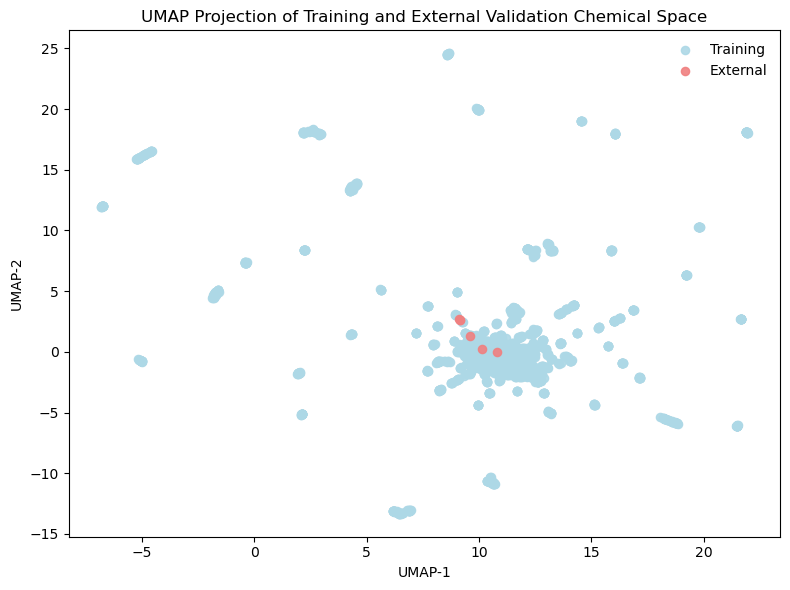

In [62]:
plt.figure(figsize=(8,6))

colors = {
    "Training": "lightblue",
    "External": "lightcoral"
}

for dataset in ["Training", "External"]:

    idx = fingerprint_all["Dataset"] == dataset

    plt.scatter(
        X_umap[idx,0],
        X_umap[idx,1],
        s=35,
        alpha=0.9,
        color=colors[dataset],
        label=dataset
    )

plt.title("UMAP Projection of Training and External Validation Chemical Space")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [63]:
import joblib

# Load Extra Trees model
ET_model = joblib.load("ET_best_model.pkl")

print("="*60)
print("Extra Trees model loaded successfully!")
print("="*60)
print(ET_model)

Extra Trees model loaded successfully!
ExtraTreesClassifier(n_estimators=500, n_jobs=-1, random_state=42)


In [64]:
hybrid_dataset.columns

Index(['Senyawa', 'SMILES', 'SMILES_Canonical', 'IC50', 'pIC50',
       'Activity_Class', 'Label', 'Bit_0', 'Bit_1', 'Bit_2',
       ...
       'SlogP', 'TPSA', 'HBA', 'HBD', 'RotatableBonds', 'AromaticRings',
       'FractionCsp3', 'MolarRefractivity', 'QED', 'HeteroatomRatio'],
      dtype='object', length=2066)

In [65]:
# ============================================================
# Prepare External Validation Data
# ============================================================

X_external = hybrid_dataset.iloc[:, 7:]
y_external = hybrid_dataset["Label"]

print("="*60)
print("External Validation Dataset")
print("="*60)
print("Feature matrix :", X_external.shape)
print("Label vector   :", y_external.shape)

External Validation Dataset
Feature matrix : (6, 2059)
Label vector   : (6,)


In [66]:
import joblib

ET_model = joblib.load("ET_best_model.pkl")

print("✅ Extra Trees model loaded.")

✅ Extra Trees model loaded.


In [67]:
# ============================================================
# External Prediction
# ============================================================

y_pred = ET_model.predict(X_external)

y_prob = ET_model.predict_proba(X_external)[:, 1]

prediction_df = hybrid_dataset[
    [
        "Senyawa",
        "Activity_Class",
        "Label"
    ]
].copy()

prediction_df["Predicted_Label"] = y_pred
prediction_df["Probability_Active"] = y_prob

display(prediction_df)

,Senyawa,Activity_Class,Label,Predicted_Label,Probability_Active
0,trans-resveratrol,Active,1,0,0.154
1,Narcissin,Inactive,0,0,0.166
2,rutin,Inactive,0,0,0.170
3,Kaempferol 3-O-alpha-L-rhamnopyranoside,Inactive,0,0,0.062
4,Sitosterol,Inactive,0,0,0.436
5,(+)-isolariciresinol,Inactive,0,0,0.028


In [68]:
prediction_df.to_csv(
    "external_validation_predictions.csv",
    index=False
)

print("✅ external_validation_predictions.csv saved")

✅ external_validation_predictions.csv saved


In [69]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("="*60)
print("External Validation Performance")
print("="*60)

# Confusion matrix
cm = confusion_matrix(y_external, y_pred)

tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(y_external, y_pred)
precision = precision_score(y_external, y_pred, zero_division=0)
recall = recall_score(y_external, y_pred, zero_division=0)
f1 = f1_score(y_external, y_pred, zero_division=0)
mcc = matthews_corrcoef(y_external, y_pred)
roc_auc = roc_auc_score(y_external, y_prob)

print(f"TN : {tn}")
print(f"FP : {fp}")
print(f"FN : {fn}")
print(f"TP : {tp}")
print("-"*60)
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"MCC      : {mcc:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

External Validation Performance
TN : 5
FP : 0
FN : 1
TP : 0
------------------------------------------------------------
Accuracy : 0.833
Precision: 0.000
Recall   : 0.000
F1-score : 0.000
MCC      : 0.000
ROC-AUC  : 0.400


In [70]:
performance_external = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "MCC",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        mcc,
        roc_auc
    ]
})

performance_external

,Metric,Value
0,Accuracy,0.833333
1,Precision,0.000000
2,Recall,0.000000
3,F1-score,0.000000
4,MCC,0.000000
5,ROC-AUC,0.400000


In [71]:
performance_external.to_csv(
    "external_validation_metrics.csv",
    index=False
)

print("✅ external_validation_metrics.csv saved")

✅ external_validation_metrics.csv saved


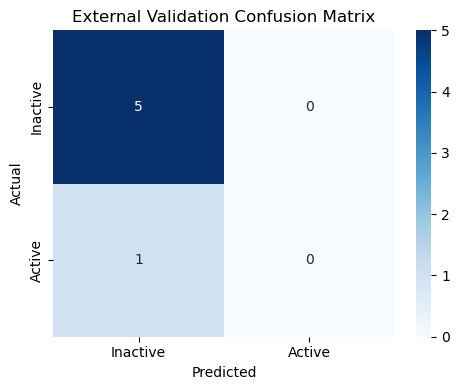

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_external, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("External Validation Confusion Matrix")

plt.tight_layout()
plt.show()

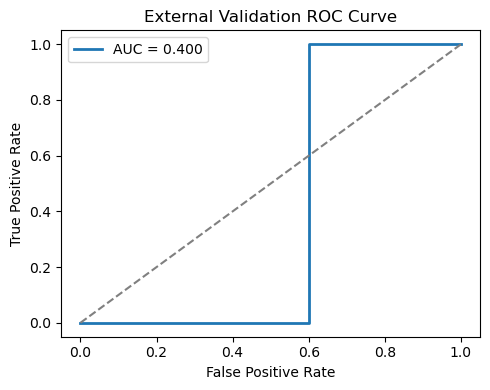

In [73]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_external, y_prob)

plt.figure(figsize=(5,4))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("External Validation ROC Curve")

plt.legend()

plt.tight_layout()
plt.show()

PUBCHEM

In [74]:
# ============================================================
# 1. Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# RDKit
from rdkit import Chem
from rdkit.Chem import SaltRemover
from rdkit.Chem import Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [75]:
# ============================================================
# 2. Load Dataset
# ============================================================

df_pubchem = pd.read_csv("dataset_cyp3a4_external_validation_clean.csv")

print("="*60)
print("PubChem External Dataset")
print("="*60)

print("Shape :", df_pubchem.shape)

display(df_pubchem.head())

PubChem External Dataset
Shape : (3564, 8)


,AID,Assay_Name,CID,Activity_Outcome,Activity_Value,Activity_Units,SMILES,InChIKey
0,622601,Inhibition of CYP3A4,1684,Active,6.30957,uM,CC1=CC(=CC(=C1OCCCC2=CC(=NO2)C)C)C3=NOC(=N3)C(F)(F)F,KQOXLKOJHVFTRN-UHFFFAOYSA-N
1,526453,Inhibition of human CYP3A4,2099,Active,0.60000,uM,CC1=C(N=CN1)CN2CCC3=C(C2=O)C4=CC=CC=C4N3C,JSWZEAMFRNKZNL-UHFFFAOYSA-N
2,1801670,"In vitro CYP3A4 Inhibition Assay from US Patent US9144538: ""Cosmetic compositions containing substituted azole and methods for alleviating the signs of photoaged skin""",2378,Active,0.80000,uM,C1=CC=C(C=C1)C2=CC=C(C=C2)C(C3=CC=CC=C3)N4C=CN=C4,OCAPBUJLXMYKEJ-UHFFFAOYSA-N
3,1833385,Inhibition of human CYP3A4 preincubated for 10 mins followed by substrate and NADP addition measured after 30 mins by fluorescence assay,2520,Active,0.01100,uM,CC(C)C(CCCN(C)CCC1=CC(=C(C=C1)OC)OC)(C#N)C2=CC(=C(C=C2)OC)OC,SGTNSNPWRIOYBX-UHFFFAOYSA-N
4,428564,Inhibition of CYP3A4,2812,Active,0.05000,uM,C1=CC=C(C=C1)C(C2=CC=CC=C2)(C3=CC=CC=C3Cl)N4C=CN=C4,VNFPBHJOKIVQEB-UHFFFAOYSA-N


In [76]:
# ============================================================
# 3. Initial Inspection
# ============================================================

print("="*60)
print("Dataset Information")
print("="*60)

display(df_pubchem.info())

print("\nMissing Values")
display(df_pubchem.isna().sum())

print("\nDuplicate Rows")
print(df_pubchem.duplicated().sum())

print("\nActivity Units")
display(df_pubchem["Activity_Units"].value_counts())

print("\nActivity Outcome")
display(df_pubchem["Activity_Outcome"].value_counts())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3564 entries, 0 to 3563
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   AID               3564 non-null   int64  
 1   Assay_Name        3564 non-null   object 
 2   CID               3564 non-null   int64  
 3   Activity_Outcome  3564 non-null   object 
 4   Activity_Value    3564 non-null   float64
 5   Activity_Units    3564 non-null   object 
 6   SMILES            3564 non-null   object 
 7   InChIKey          3564 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 222.9+ KB


None


Missing Values


AID                 0
Assay_Name          0
CID                 0
Activity_Outcome    0
Activity_Value      0
Activity_Units      0
SMILES              0
InChIKey            0
dtype: int64


Duplicate Rows
0

Activity Units


Activity_Units
uM    3564
Name: count, dtype: int64


Activity Outcome


Activity_Outcome
Active      3446
Inactive     118
Name: count, dtype: int64

In [77]:
# ============================================================
# 4. Structure Curation
# ============================================================

df_pubchem["Mol"] = df_pubchem["SMILES"].apply(
    Chem.MolFromSmiles
)

print("="*60)
print("SMILES to Molecule")
print("="*60)

print("Invalid molecules :", df_pubchem["Mol"].isna().sum())
print("Valid molecules   :", df_pubchem["Mol"].notna().sum())

SMILES to Molecule
Invalid molecules : 0
Valid molecules   : 3564


In [78]:
before = len(df_pubchem)

df_pubchem = df_pubchem[
    df_pubchem["Mol"].notna()
].reset_index(drop=True)

after = len(df_pubchem)

print("="*60)
print("Remove Invalid Molecules")
print("="*60)

print("Before :", before)
print("After  :", after)
print("Removed:", before-after)

Remove Invalid Molecules
Before : 3564
After  : 3564
Removed: 0


In [79]:
# ============================================================
# 5. Remove Salts
# ============================================================

from rdkit.Chem import SaltRemover

remover = SaltRemover.SaltRemover()

df_pubchem["Mol_NoSalt"] = df_pubchem["Mol"].apply(
    lambda mol: remover.StripMol(mol, dontRemoveEverything=True)
)

df_pubchem["SMILES_NoSalt"] = df_pubchem["Mol_NoSalt"].apply(
    Chem.MolToSmiles
)

print("="*60)
print("Salt Removal")
print("="*60)
print(df_pubchem.shape)

display(
    df_pubchem[
        ["SMILES", "SMILES_NoSalt"]
    ].head()
)

Salt Removal
(3564, 11)


,SMILES,SMILES_NoSalt
0,CC1=CC(=CC(=C1OCCCC2=CC(=NO2)C)C)C3=NOC(=N3)C(F)(F)F,Cc1cc(CCCOc2c(C)cc(-c3noc(C(F)(F)F)n3)cc2C)on1
1,CC1=C(N=CN1)CN2CCC3=C(C2=O)C4=CC=CC=C4N3C,Cc1[nH]cnc1CN1CCc2c(c3ccccc3n2C)C1=O
2,C1=CC=C(C=C1)C2=CC=C(C=C2)C(C3=CC=CC=C3)N4C=CN=C4,c1ccc(-c2ccc(C(c3ccccc3)n3ccnc3)cc2)cc1
3,CC(C)C(CCCN(C)CCC1=CC(=C(C=C1)OC)OC)(C#N)C2=CC(=C(C=C2)OC)OC,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC
4,C1=CC=C(C=C1)C(C2=CC=CC=C2)(C3=CC=CC=C3Cl)N4C=CN=C4,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1


In [80]:
# ============================================================
# 6. Remove Inorganic Molecules
# ============================================================

before = len(df_pubchem)

df_pubchem = df_pubchem[
    df_pubchem["Mol_NoSalt"].apply(
        lambda mol: mol.GetNumAtoms() > 1
    )
].reset_index(drop=True)

after = len(df_pubchem)

print("="*60)
print("Remove Inorganic Molecules")
print("="*60)

print("Before :", before)
print("After  :", after)
print("Removed:", before-after)

Remove Inorganic Molecules
Before : 3564
After  : 3564
Removed: 0


In [81]:
# ============================================================
# 8. Canonical SMILES
# ============================================================

df_pubchem["SMILES_Canonical"] = df_pubchem[
    "Mol_Standardized"
].apply(
    lambda mol: Chem.MolToSmiles(
        mol,
        canonical=True
    )
)

print("="*60)
print("Canonical SMILES")
print("="*60)

display(
    df_pubchem[
        [
            "SMILES_Standardized",
            "SMILES_Canonical"
        ]
    ].head()
)

KeyError: 'Mol_Standardized'

In [82]:
print(df_pubchem.columns.tolist())

['AID', 'Assay_Name', 'CID', 'Activity_Outcome', 'Activity_Value', 'Activity_Units', 'SMILES', 'InChIKey', 'Mol', 'Mol_NoSalt', 'SMILES_NoSalt']


In [83]:
# ============================================================
# 7. Structure Standardization
# ============================================================

from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import Chem

df_pubchem["Mol_Standardized"] = df_pubchem["Mol_NoSalt"].apply(
    lambda mol: rdMolStandardize.Cleanup(mol)
)

df_pubchem["SMILES_Standardized"] = df_pubchem["Mol_Standardized"].apply(
    lambda mol: Chem.MolToSmiles(mol)
)

print("="*60)
print("Structure Standardization")
print("="*60)
print(df_pubchem.shape)

display(
    df_pubchem[
        ["SMILES_NoSalt", "SMILES_Standardized"]
    ].head()
)

[20:18:55] Initializing MetalDisconnector
[20:18:55] Running MetalDisconnector
[20:18:55] Initializing Normalizer
[20:18:55] Running Normalizer
[20:18:55] Initializing MetalDisconnector
[20:18:55] Running MetalDisconnector
[20:18:55] Initializing Normalizer
[20:18:55] Running Normalizer
[20:18:55] Initializing MetalDisconnector
[20:18:55] Running MetalDisconnector
[20:18:55] Initializing Normalizer
[20:18:55] Running Normalizer
[20:18:55] Initializing MetalDisconnector
[20:18:55] Running MetalDisconnector
[20:18:55] Initializing Normalizer
[20:18:55] Running Normalizer
[20:18:55] Initializing MetalDisconnector
[20:18:55] Running MetalDisconnector
[20:18:55] Initializing Normalizer
[20:18:55] Running Normalizer
[20:18:55] Initializing MetalDisconnector
[20:18:55] Running MetalDisconnector
[20:18:55] Initializing Normalizer
[20:18:55] Running Normalizer
[20:18:55] Initializing MetalDisconnector
[20:18:55] Running MetalDisconnector
[20:18:55] Initializing Normalizer
[20:18:55] Running Nor

Structure Standardization
(3564, 13)


,SMILES_NoSalt,SMILES_Standardized
0,Cc1cc(CCCOc2c(C)cc(-c3noc(C(F)(F)F)n3)cc2C)on1,Cc1cc(CCCOc2c(C)cc(-c3noc(C(F)(F)F)n3)cc2C)on1
1,Cc1[nH]cnc1CN1CCc2c(c3ccccc3n2C)C1=O,Cc1[nH]cnc1CN1CCc2c(c3ccccc3n2C)C1=O
2,c1ccc(-c2ccc(C(c3ccccc3)n3ccnc3)cc2)cc1,c1ccc(-c2ccc(C(c3ccccc3)n3ccnc3)cc2)cc1
3,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC
4,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1


In [84]:
print(df_pubchem.columns.tolist())

['AID', 'Assay_Name', 'CID', 'Activity_Outcome', 'Activity_Value', 'Activity_Units', 'SMILES', 'InChIKey', 'Mol', 'Mol_NoSalt', 'SMILES_NoSalt', 'Mol_Standardized', 'SMILES_Standardized']


In [85]:
# ============================================================
# 8. Canonical SMILES
# ============================================================

df_pubchem["SMILES_Canonical"] = df_pubchem["Mol_Standardized"].apply(
    lambda mol: Chem.MolToSmiles(mol, canonical=True)
)

display(
    df_pubchem[
        ["SMILES_Standardized", "SMILES_Canonical"]
    ].head()
)

,SMILES_Standardized,SMILES_Canonical
0,Cc1cc(CCCOc2c(C)cc(-c3noc(C(F)(F)F)n3)cc2C)on1,Cc1cc(CCCOc2c(C)cc(-c3noc(C(F)(F)F)n3)cc2C)on1
1,Cc1[nH]cnc1CN1CCc2c(c3ccccc3n2C)C1=O,Cc1[nH]cnc1CN1CCc2c(c3ccccc3n2C)C1=O
2,c1ccc(-c2ccc(C(c3ccccc3)n3ccnc3)cc2)cc1,c1ccc(-c2ccc(C(c3ccccc3)n3ccnc3)cc2)cc1
3,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC
4,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1


In [86]:
print("="*60)
print("Duplicate Canonical SMILES")
print("="*60)

dup = df_pubchem["SMILES_Canonical"].duplicated().sum()

print(f"Duplicate structures : {dup}")

Duplicate Canonical SMILES
Duplicate structures : 0


In [87]:
training = pd.read_csv("cyp3a4_binary_final_dataset.csv")

print(training.shape)

(1756, 8)


In [88]:
training_smiles = set(training["SMILES"])

In [89]:
print("="*60)
print("Step 10 - Remove Training Overlap")
print("="*60)

before = len(df_pubchem)

df_pubchem = df_pubchem[
    ~df_pubchem["SMILES_Canonical"].isin(training_smiles)
].reset_index(drop=True)

after = len(df_pubchem)

print(f"Compounds before : {before}")
print(f"Compounds after  : {after}")
print(f"Removed          : {before-after}")

Step 10 - Remove Training Overlap
Compounds before : 3564
Compounds after  : 2898
Removed          : 666


In [90]:
df_pubchem.to_csv(
    "pubchem_external_no_training_overlap.csv",
    index=False
)

print("✅ pubchem_external_no_training_overlap.csv saved")

✅ pubchem_external_no_training_overlap.csv saved


In [91]:
# Load herbal dataset
herbal = pd.read_csv("external_validation_final.csv")

# Cek jumlah overlap
before = len(df_pubchem)

herbal_smiles = set(herbal["SMILES_Canonical"])

df_pubchem = df_pubchem[
    ~df_pubchem["SMILES_Canonical"].isin(herbal_smiles)
].reset_index(drop=True)

after = len(df_pubchem)

print("="*60)
print("Step 11 - Remove Herbal Overlap")
print("="*60)
print(f"Compounds before : {before}")
print(f"Compounds after  : {after}")
print(f"Removed          : {before-after}")

Step 11 - Remove Herbal Overlap
Compounds before : 2898
Compounds after  : 2897
Removed          : 1


In [92]:
df_pubchem.to_csv(
    "pubchem_external_no_overlap.csv",
    index=False
)

print("✅ pubchem_external_no_overlap.csv saved")

✅ pubchem_external_no_overlap.csv saved


In [93]:
# ============================================================
# Step 12 - Convert Activity Value (μM) to IC50 (nM)
# ============================================================

df_pubchem["IC50_nM"] = df_pubchem["Activity_Value"] * 1000

print("="*60)
print("Convert μM to nM")
print("="*60)

display(
    df_pubchem[
        [
            "Activity_Value",
            "Activity_Units",
            "IC50_nM"
        ]
    ].head()
)

Convert μM to nM


,Activity_Value,Activity_Units,IC50_nM
0,6.30957,uM,6309.57
1,0.60000,uM,600.00
2,0.80000,uM,800.00
3,0.01100,uM,11.00
4,0.43000,uM,430.00


In [94]:
# ============================================================
# Step 13 - Convert IC50 (nM) to pIC50
# ============================================================

df_pubchem["pIC50"] = -np.log10(df_pubchem["IC50_nM"] * 1e-9)

print("="*60)
print("Convert IC50 (nM) to pIC50")
print("="*60)

display(
    df_pubchem[
        [
            "IC50_nM",
            "pIC50"
        ]
    ].head()
)

Convert IC50 (nM) to pIC50


,IC50_nM,pIC50
0,6309.57,5.200000
1,600.00,6.221849
2,800.00,6.096910
3,11.00,7.958607
4,430.00,6.366532


In [95]:
# ============================================================
# Step 14 - Activity Labeling
# ============================================================

def activity_class(pic50):

    if pic50 >= 6:
        return "Active"

    elif pic50 < 5:
        return "Inactive"

    else:
        return "Intermediate"

df_pubchem["Activity_Class"] = (
    df_pubchem["pIC50"]
    .apply(activity_class)
)

print("="*60)
print("Activity Class Distribution")
print("="*60)

print(df_pubchem["Activity_Class"].value_counts())

Activity Class Distribution
Activity_Class
Intermediate    2132
Active           631
Inactive         134
Name: count, dtype: int64


In [96]:
before = len(df_pubchem)

df_pubchem = df_pubchem[
    df_pubchem["Activity_Class"] != "Intermediate"
].reset_index(drop=True)

after = len(df_pubchem)

print("="*60)
print("Remove Intermediate Compounds")
print("="*60)

print(f"Compounds before : {before}")
print(f"Compounds after  : {after}")
print(f"Removed          : {before-after}")

Remove Intermediate Compounds
Compounds before : 2897
Compounds after  : 765
Removed          : 2132


In [97]:
label_map = {
    "Inactive": 0,
    "Active": 1
}

df_pubchem["Label"] = df_pubchem["Activity_Class"].map(label_map)

print(df_pubchem["Label"].value_counts())

Label
1    631
0    134
Name: count, dtype: int64


In [98]:
df_pubchem.to_csv(
    "pubchem_external_final.csv",
    index=False
)

print("✅ pubchem_external_final.csv saved")

✅ pubchem_external_final.csv saved


In [99]:
# ============================================================
# Step 17 - Add Source
# ============================================================

df_pubchem["Source"] = "PubChem BioAssay"

In [100]:
df_pubchem = df_pubchem.rename(
    columns={
        "AID": "Assay_ID",
        "Assay_Name": "Assay_Description",
        "IC50_nM": "IC50"
    }
)

In [101]:
df_pubchem["Senyawa"] = np.nan

In [102]:
final_columns = [
    "Source",
    "CID",
    "Senyawa",
    "SMILES",
    "SMILES_Canonical",
    "IC50",
    "Assay_ID",
    "Assay_Description",
    "pIC50",
    "Activity_Class",
    "Label"
]

df_pubchem = df_pubchem[final_columns]

In [103]:
df_pubchem.head()

,Source,CID,Senyawa,SMILES,SMILES_Canonical,IC50,Assay_ID,Assay_Description,pIC50,Activity_Class,Label
0,PubChem BioAssay,2099,NaN,CC1=C(N=CN1)CN2CCC3=C(C2=O)C4=CC=CC=C4N3C,Cc1[nH]cnc1CN1CCc2c(c3ccccc3n2C)C1=O,600.0,526453,Inhibition of human CYP3A4,6.221849,Active,1
1,PubChem BioAssay,2378,NaN,C1=CC=C(C=C1)C2=CC=C(C=C2)C(C3=CC=CC=C3)N4C=CN=C4,c1ccc(-c2ccc(C(c3ccccc3)n3ccnc3)cc2)cc1,800.0,1801670,"In vitro CYP3A4 Inhibition Assay from US Patent US9144538: ""Cosmetic compositions containing substituted azole and methods for alleviating the signs of photoaged skin""",6.096910,Active,1
2,PubChem BioAssay,2520,NaN,CC(C)C(CCCN(C)CCC1=CC(=C(C=C1)OC)OC)(C#N)C2=CC(=C(C=C2)OC)OC,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC,11.0,1833385,Inhibition of human CYP3A4 preincubated for 10 mins followed by substrate and NADP addition measured after 30 mins by fluorescence assay,7.958607,Active,1
3,PubChem BioAssay,3198,NaN,C1=CC(=CC=C1COC(CN2C=CN=C2)C3=C(C=C(C=C3)Cl)Cl)Cl,Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)cc2Cl)cc1,430.0,1634154,Inhibition of CYP3A4 (unknown origin),6.366532,Active,1
4,PubChem BioAssay,3793,NaN,CCC(C)N1C(=O)N(C=N1)C2=CC=C(C=C2)N3CCN(CC3)C4=CC=C(C=C4)OCC5COC(O5)(CN6C=NC=N6)C7=C(C=C(C=C7)Cl)Cl,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn6)(c6ccc(Cl)cc6Cl)O5)cc4)CC3)cc2)c1=O,32.6,1334864,Inhibition of CYP3A4 in human liver microsomes assessed as reduction in nifedipine oxidation incubated for 10 mins,7.486782,Active,1


In [104]:
df_pubchem["Source"] = "PubChem BioAssay"

df_pubchem = df_pubchem.rename(
    columns={
        "AID": "Assay_ID",
        "Assay_Name": "Assay_Description",
        "IC50_nM": "IC50"
    }
)

final_columns = [
    "Source",
    "CID",
    "SMILES",
    "SMILES_Canonical",
    "IC50",
    "Assay_ID",
    "Assay_Description",
    "pIC50",
    "Activity_Class",
    "Label"
]

df_pubchem = df_pubchem[final_columns]

In [105]:
df_pubchem.head()

,Source,CID,SMILES,SMILES_Canonical,IC50,Assay_ID,Assay_Description,pIC50,Activity_Class,Label
0,PubChem BioAssay,2099,CC1=C(N=CN1)CN2CCC3=C(C2=O)C4=CC=CC=C4N3C,Cc1[nH]cnc1CN1CCc2c(c3ccccc3n2C)C1=O,600.0,526453,Inhibition of human CYP3A4,6.221849,Active,1
1,PubChem BioAssay,2378,C1=CC=C(C=C1)C2=CC=C(C=C2)C(C3=CC=CC=C3)N4C=CN=C4,c1ccc(-c2ccc(C(c3ccccc3)n3ccnc3)cc2)cc1,800.0,1801670,"In vitro CYP3A4 Inhibition Assay from US Patent US9144538: ""Cosmetic compositions containing substituted azole and methods for alleviating the signs of photoaged skin""",6.096910,Active,1
2,PubChem BioAssay,2520,CC(C)C(CCCN(C)CCC1=CC(=C(C=C1)OC)OC)(C#N)C2=CC(=C(C=C2)OC)OC,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC,11.0,1833385,Inhibition of human CYP3A4 preincubated for 10 mins followed by substrate and NADP addition measured after 30 mins by fluorescence assay,7.958607,Active,1
3,PubChem BioAssay,3198,C1=CC(=CC=C1COC(CN2C=CN=C2)C3=C(C=C(C=C3)Cl)Cl)Cl,Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)cc2Cl)cc1,430.0,1634154,Inhibition of CYP3A4 (unknown origin),6.366532,Active,1
4,PubChem BioAssay,3793,CCC(C)N1C(=O)N(C=N1)C2=CC=C(C=C2)N3CCN(CC3)C4=CC=C(C=C4)OCC5COC(O5)(CN6C=NC=N6)C7=C(C=C(C=C7)Cl)Cl,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn6)(c6ccc(Cl)cc6Cl)O5)cc4)CC3)cc2)c1=O,32.6,1334864,Inhibition of CYP3A4 in human liver microsomes assessed as reduction in nifedipine oxidation incubated for 10 mins,7.486782,Active,1


In [106]:
df_pubchem.to_csv(
    "pubchem_external_final.csv",
    index=False
)

print("✅ pubchem_external_final.csv saved")

✅ pubchem_external_final.csv saved


merge

In [107]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import QED

import matplotlib.pyplot as plt
import seaborn as sns

import umap.umap_ as umap

import joblib

In [109]:
# ============================================================
# Load External Validation Dataset
# ============================================================

df_pubchem = pd.read_csv("pubchem_external_final.csv")

df_herbal = pd.read_csv("herbal_external_final.csv")

print("="*60)
print("PubChem :", df_pubchem.shape)
print("Herbal  :", df_herbal.shape)

PubChem : (765, 10)
Herbal  : (6, 16)


In [110]:
print(df_pubchem.columns.tolist())

print(df_herbal.columns.tolist())

['Source', 'CID', 'SMILES', 'SMILES_Canonical', 'IC50', 'Assay_ID', 'Assay_Description', 'pIC50', 'Activity_Class', 'Label']
['CID', 'SMILES', 'InChIKey', 'PubChem_Status', 'Senyawa', 'IC50', 'Unit', 'Assay_ID', 'Assay_Description', 'Mol', 'Mol_Standardized', 'SMILES_Standardized', 'SMILES_Canonical', 'pIC50', 'Activity_Class', 'Label']


In [111]:
df_herbal["Source"] = "Herbal"

In [112]:
df_herbal = df_herbal[
    [
        "Source",
        "CID",
        "SMILES",
        "SMILES_Canonical",
        "IC50",
        "Assay_ID",
        "Assay_Description",
        "pIC50",
        "Activity_Class",
        "Label"
    ]
]

In [113]:
print(df_pubchem.columns.tolist())
print(df_herbal.columns.tolist())

['Source', 'CID', 'SMILES', 'SMILES_Canonical', 'IC50', 'Assay_ID', 'Assay_Description', 'pIC50', 'Activity_Class', 'Label']
['Source', 'CID', 'SMILES', 'SMILES_Canonical', 'IC50', 'Assay_ID', 'Assay_Description', 'pIC50', 'Activity_Class', 'Label']


In [114]:
external_validation = pd.concat(
    [df_pubchem, df_herbal],
    ignore_index=True
)

print("="*60)
print("Merged External Validation Dataset")
print("="*60)

print(external_validation.shape)

display(external_validation.head())

Merged External Validation Dataset
(771, 10)


,Source,CID,SMILES,SMILES_Canonical,IC50,Assay_ID,Assay_Description,pIC50,Activity_Class,Label
0,PubChem BioAssay,2099,CC1=C(N=CN1)CN2CCC3=C(C2=O)C4=CC=CC=C4N3C,Cc1[nH]cnc1CN1CCc2c(c3ccccc3n2C)C1=O,600.0,526453,Inhibition of human CYP3A4,6.221849,Active,1
1,PubChem BioAssay,2378,C1=CC=C(C=C1)C2=CC=C(C=C2)C(C3=CC=CC=C3)N4C=CN=C4,c1ccc(-c2ccc(C(c3ccccc3)n3ccnc3)cc2)cc1,800.0,1801670,"In vitro CYP3A4 Inhibition Assay from US Patent US9144538: ""Cosmetic compositions containing substituted azole and methods for alleviating the signs of photoaged skin""",6.096910,Active,1
2,PubChem BioAssay,2520,CC(C)C(CCCN(C)CCC1=CC(=C(C=C1)OC)OC)(C#N)C2=CC(=C(C=C2)OC)OC,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC,11.0,1833385,Inhibition of human CYP3A4 preincubated for 10 mins followed by substrate and NADP addition measured after 30 mins by fluorescence assay,7.958607,Active,1
3,PubChem BioAssay,3198,C1=CC(=CC=C1COC(CN2C=CN=C2)C3=C(C=C(C=C3)Cl)Cl)Cl,Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)cc2Cl)cc1,430.0,1634154,Inhibition of CYP3A4 (unknown origin),6.366532,Active,1
4,PubChem BioAssay,3793,CCC(C)N1C(=O)N(C=N1)C2=CC=C(C=C2)N3CCN(CC3)C4=CC=C(C=C4)OCC5COC(O5)(CN6C=NC=N6)C7=C(C=C(C=C7)Cl)Cl,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn6)(c6ccc(Cl)cc6Cl)O5)cc4)CC3)cc2)c1=O,32.6,1334864,Inhibition of CYP3A4 in human liver microsomes assessed as reduction in nifedipine oxidation incubated for 10 mins,7.486782,Active,1


In [115]:
print("="*60)
print("Quality Control")
print("="*60)

print(
    "Duplicate Canonical SMILES :",
    external_validation["SMILES_Canonical"].duplicated().sum()
)

print()

print(
    external_validation["Source"].value_counts()
)

Quality Control
Duplicate Canonical SMILES : 0

Source
PubChem BioAssay    765
Herbal                6
Name: count, dtype: int64


In [116]:
print("="*60)
print("External Validation Dataset")
print("="*60)

print("Shape :", external_validation.shape)

External Validation Dataset
Shape : (771, 10)


In [117]:
print("="*60)
print("Source Distribution")
print("="*60)

print(external_validation["Source"].value_counts())

Source Distribution
Source
PubChem BioAssay    765
Herbal                6
Name: count, dtype: int64


In [118]:
print("="*60)
print("Activity Class Distribution")
print("="*60)

print(external_validation["Activity_Class"].value_counts())

Activity Class Distribution
Activity_Class
Active      632
Inactive    139
Name: count, dtype: int64


In [119]:
print("="*60)
print("Binary Label Distribution")
print("="*60)

print(external_validation["Label"].value_counts())

Binary Label Distribution
Label
1    632
0    139
Name: count, dtype: int64


In [120]:
print("="*60)
print("Duplicate Structures")
print("="*60)

print(
    external_validation["SMILES_Canonical"].duplicated().sum()
)

Duplicate Structures
0


In [121]:
print("="*60)
print("Missing Values")
print("="*60)

print(external_validation.isna().sum())

Missing Values
Source               0
CID                  0
SMILES               0
SMILES_Canonical     0
IC50                 0
Assay_ID             0
Assay_Description    0
pIC50                0
Activity_Class       0
Label                0
dtype: int64


generasi fitur

In [122]:
external_validation.to_csv(
    "external_validation_final.csv",
    index=False
)

print("✅ external_validation_final.csv saved")

✅ external_validation_final.csv saved


In [123]:
# ============================================================
# Generate Molecule Object
# ============================================================

external_validation["Mol"] = external_validation["SMILES"].apply(
    Chem.MolFromSmiles
)

print("="*60)
print("Molecule Generation")
print("="*60)

print(
    external_validation["Mol"].isna().sum(),
    "invalid molecules"
)

Molecule Generation
0 invalid molecules


In [124]:
from rdkit.Chem import AllChem

def mol_to_ecfp4(mol, radius=2, n_bits=2048):

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    return list(fp)

fingerprint_data = pd.DataFrame(
    external_validation["Mol"]
    .apply(mol_to_ecfp4)
    .tolist()
)

print("="*60)
print("ECFP4 Fingerprint")
print("="*60)

print("Fingerprint matrix :", fingerprint_data.shape)

[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerator
[20:53:01] DEPRECATION WARNING: please use MorganGenerat

ECFP4 Fingerprint
Fingerprint matrix : (771, 2048)


In [125]:
# ============================================================
# RDKit Descriptors
# ============================================================

from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import QED

def calculate_descriptors(mol):

    heavy_atoms = Descriptors.HeavyAtomCount(mol)

    return pd.Series({
        "MW": Descriptors.MolWt(mol),
        "SlogP": Descriptors.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCsp3": rdMolDescriptors.CalcFractionCSP3(mol),
        "MolarRefractivity": Descriptors.MolMR(mol),
        "QED": QED.qed(mol),
        "HeteroatomRatio": (
            rdMolDescriptors.CalcNumHeteroatoms(mol) / heavy_atoms
            if heavy_atoms > 0 else 0
        )
    })

descriptor_data = external_validation["Mol"].apply(
    calculate_descriptors
)

print("="*60)
print("RDKit Descriptors")
print("="*60)

print("Descriptor matrix :", descriptor_data.shape)

descriptor_data.head()

RDKit Descriptors
Descriptor matrix : (771, 11)


,MW,SlogP,TPSA,HBA,HBD,RotatableBonds,AromaticRings,FractionCsp3,MolarRefractivity,QED,HeteroatomRatio
0,294.358,2.40832,53.92,2.0,1.0,2.0,3.0,0.294118,84.6882,0.788848,0.227273
1,310.400,5.18780,17.82,1.0,0.0,4.0,4.0,0.045455,97.7880,0.507136,0.083333
2,454.611,5.09308,63.95,6.0,0.0,13.0,2.0,0.518519,131.6560,0.419905,0.181818
3,381.690,5.80140,27.05,2.0,0.0,6.0,3.0,0.166667,97.6710,0.539187,0.250000
4,705.647,5.57730,104.70,9.0,0.0,11.0,5.0,0.371429,188.1760,0.174394,0.285714


In [126]:
# ============================================================
# Hybrid Feature
# ============================================================

hybrid_data = pd.concat(
    [
        fingerprint_data,
        descriptor_data
    ],
    axis=1
)

print("="*60)
print("Hybrid Feature")
print("="*60)

print("Hybrid matrix :", hybrid_data.shape)

Hybrid Feature
Hybrid matrix : (771, 2059)


In [127]:
# ============================================================
# Save Hybrid Dataset
# ============================================================

hybrid_final = pd.concat(
    [
        external_validation.reset_index(drop=True),
        hybrid_data.reset_index(drop=True)
    ],
    axis=1
)

hybrid_final.to_csv(
    "external_validation_hybrid.csv",
    index=False
)

print("✅ external_validation_hybrid.csv saved")

✅ external_validation_hybrid.csv saved


In [128]:
training = pd.read_csv("training_hybrid.csv")

print(training.shape)

(1756, 2066)


In [129]:
X_train = training.iloc[:, -2059:]

In [130]:
X_external = hybrid_data

In [131]:
X_all = pd.concat(
    [
        X_train,
        X_external
    ],
    ignore_index=True
)

print(X_all.shape)

(2527, 4107)


In [132]:
import umap.umap_ as umap

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_all)

print(X_umap.shape)

ValueError: Input contains NaN.

In [133]:
print(X_train.isna().sum().sum())
print(X_external.isna().sum().sum())

0
0


In [134]:
print(X_train.columns[X_train.isna().any()])

print(X_external.columns[X_external.isna().any()])

Index([], dtype='object')
Index([], dtype='object')


In [135]:
print(descriptor_data.isna().sum())

MW                   0
SlogP                0
TPSA                 0
HBA                  0
HBD                  0
RotatableBonds       0
AromaticRings        0
FractionCsp3         0
MolarRefractivity    0
QED                  0
HeteroatomRatio      0
dtype: int64


In [136]:
print(X_train.shape)
print(X_external.shape)

(1756, 2059)
(771, 2059)


In [137]:
print("Training NaN :", X_train.isna().sum().sum())

print("External NaN :", X_external.isna().sum().sum())

Training NaN : 0
External NaN : 0


In [138]:
print(X_all.shape)

print("NaN:", X_all.isna().sum().sum())

(2527, 4107)
NaN: 5175296


In [139]:
print(X_train.columns[:20])

print(X_external.columns[:20])

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19'],
      dtype='object')
Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], dtype='object')


In [140]:
# Samakan nama kolom fingerprint training dengan external
X_train.columns = [
    int(col) if str(col).isdigit() else col
    for col in X_train.columns
]

In [141]:
print(X_train.columns[:20])
print(X_external.columns[:20])

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], dtype='object')
Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], dtype='object')


In [142]:
X_all = pd.concat(
    [X_train, X_external],
    ignore_index=True
)

print(X_all.shape)
print("NaN:", X_all.isna().sum().sum())

(2527, 2059)
NaN: 0


In [143]:
import umap.umap_ as umap

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_all)

print(X_umap.shape)

(2527, 2)


In [144]:
# ============================================================
# Split UMAP Coordinates
# ============================================================

train_umap = X_umap[:len(X_train)]

external_umap = X_umap[len(X_train):]

print(train_umap.shape)
print(external_umap.shape)

(1756, 2)
(771, 2)


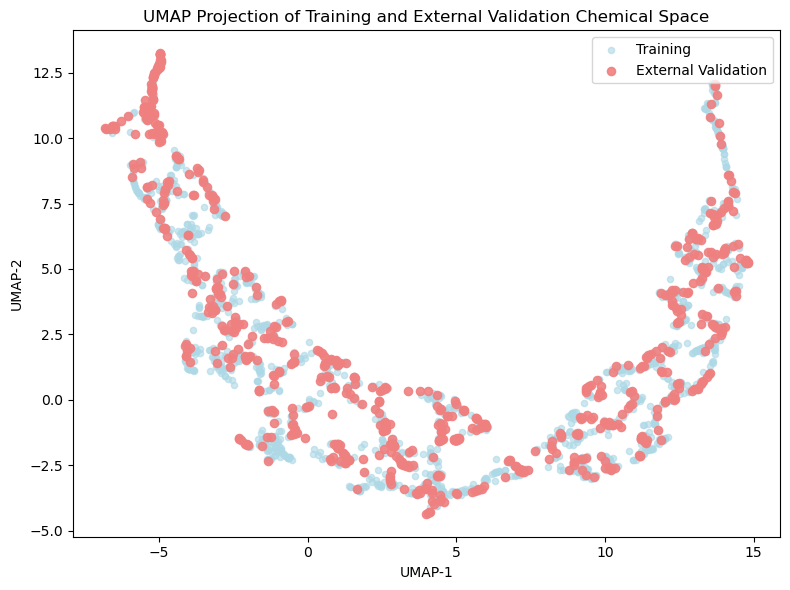

In [145]:
# ============================================================
# UMAP Chemical Space
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    train_umap[:,0],
    train_umap[:,1],
    color="lightblue",
    s=20,
    alpha=0.6,
    label="Training"
)

plt.scatter(
    external_umap[:,0],
    external_umap[:,1],
    color="lightcoral",
    s=35,
    alpha=0.9,
    label="External Validation"
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.title("UMAP Projection of Training and External Validation Chemical Space")

plt.legend()

plt.tight_layout()

plt.show()

In [146]:
# ============================================================
# Combine Training and External Fingerprints
# ============================================================

# fingerprint_train = fingerprint training (1756 x 2048)
# fingerprint_data  = fingerprint external (771 x 2048)

# Samakan nama kolom (penting!)
fingerprint_train.columns = fingerprint_data.columns

# Tambahkan label dataset
fingerprint_train["Dataset"] = "Training"
fingerprint_data["Dataset"] = "External"

# Gabungkan
fingerprint_all = pd.concat(
    [fingerprint_train, fingerprint_data],
    ignore_index=True
)

print("="*60)
print("Combined Fingerprint Dataset")
print("="*60)
print(fingerprint_all.shape)

ValueError: Length mismatch: Expected axis has 2049 elements, new values have 2048 elements

In [147]:
print(fingerprint_train.shape)
print(fingerprint_data.shape)

print(fingerprint_train.columns[-5:])
print(fingerprint_data.columns[-5:])

(1756, 2049)
(771, 2048)
Index([2044, 2045, 2046, 2047, 'Dataset'], dtype='object')
RangeIndex(start=2043, stop=2048, step=1)


In [148]:
fingerprint_train = fingerprint_train.drop(
    columns="Dataset",
    errors="ignore"
)

fingerprint_data = fingerprint_data.drop(
    columns="Dataset",
    errors="ignore"
)

In [149]:
fingerprint_train.columns = fingerprint_data.columns

In [150]:
fingerprint_train["Dataset"] = "Training"
fingerprint_data["Dataset"] = "External"

In [151]:
print(fingerprint_train.shape)
print(fingerprint_data.shape)

print(fingerprint_train.columns[-10:])
print(fingerprint_data.columns[-10:])

(1756, 2049)
(771, 2049)
Index([2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 'Dataset'], dtype='object')
Index([2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 'Dataset'], dtype='object')


In [152]:
fingerprint_all = pd.concat(
    [fingerprint_train, fingerprint_data],
    ignore_index=True
)

print(fingerprint_all.shape)

(2527, 2049)


In [153]:
import umap.umap_ as umap

X_fp = fingerprint_all.drop(columns="Dataset")

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_fp)

print(X_umap.shape)

(2527, 2)


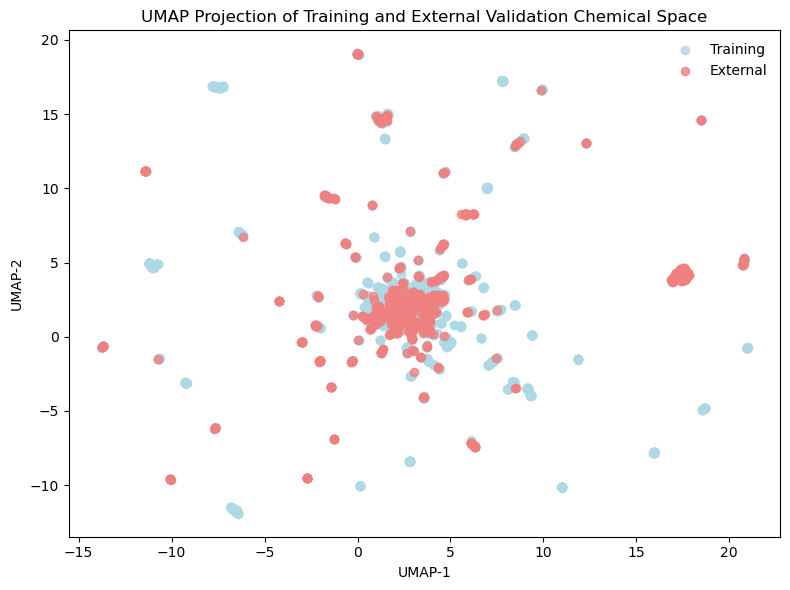

In [154]:
plt.figure(figsize=(8,6))

colors = {
    "Training": "lightblue",
    "External": "lightcoral"
}

for dataset in ["Training", "External"]:

    idx = fingerprint_all["Dataset"] == dataset

    plt.scatter(
        X_umap[idx,0],
        X_umap[idx,1],
        s=35,
        alpha=0.8,
        color=colors[dataset],
        label=dataset
    )

plt.title("UMAP Projection of Training and External Validation Chemical Space")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
Validasi

In [157]:
# ============================================================
# Load Best Model
# ============================================================

import joblib

model = joblib.load("ET_best_model.pkl")

print(model)

ExtraTreesClassifier(n_estimators=500, n_jobs=-1, random_state=42)


In [158]:
# ============================================================
# Feature Matrix
# ============================================================

X_external = hybrid_data

y_external = external_validation["Label"]

print(X_external.shape)
print(y_external.shape)

(771, 2059)
(771,)


In [159]:
# ============================================================
# Prediction
# ============================================================

y_pred = model.predict(X_external)

y_prob = model.predict_proba(X_external)[:,1]

TypeError: Feature names are only supported if all input features have string names, but your input has ['int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.

In [160]:
X_external = hybrid_data.copy()

X_external.columns = X_external.columns.astype(str)

print(X_external.columns[:10])

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='object')


In [161]:
y_pred = model.predict(X_external)

y_prob = model.predict_proba(X_external)[:,1]

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- 0
- 1
- 10
- 100
- 1000
- ...
Feature names seen at fit time, yet now missing:
- Bit_0
- Bit_1
- Bit_10
- Bit_100
- Bit_1000
- ...


In [162]:
print(model.n_features_in_)

print(model.feature_names_in_[:15])
print(model.feature_names_in_[-15:])

print(X_external.columns[:15])
print(X_external.columns[-15:])

2059
['Bit_0' 'Bit_1' 'Bit_2' 'Bit_3' 'Bit_4' 'Bit_5' 'Bit_6' 'Bit_7' 'Bit_8'
 'Bit_9' 'Bit_10' 'Bit_11' 'Bit_12' 'Bit_13' 'Bit_14']
['Bit_2044' 'Bit_2045' 'Bit_2046' 'Bit_2047' 'MW' 'SlogP' 'TPSA' 'HBA'
 'HBD' 'RotatableBonds' 'AromaticRings' 'FractionCsp3' 'MolarRefractivity'
 'QED' 'HeteroatomRatio']
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14'],
      dtype='object')
Index(['2044', '2045', '2046', '2047', 'MW', 'SlogP', 'TPSA', 'HBA', 'HBD',
       'RotatableBonds', 'AromaticRings', 'FractionCsp3', 'MolarRefractivity',
       'QED', 'HeteroatomRatio'],
      dtype='object')


In [163]:
# Rename fingerprint columns
X_external.columns = [
    f"Bit_{col}" if str(col).isdigit() else col
    for col in X_external.columns
]

In [164]:
print(X_external.columns[:15])

Index(['Bit_0', 'Bit_1', 'Bit_2', 'Bit_3', 'Bit_4', 'Bit_5', 'Bit_6', 'Bit_7',
       'Bit_8', 'Bit_9', 'Bit_10', 'Bit_11', 'Bit_12', 'Bit_13', 'Bit_14'],
      dtype='object')


In [166]:
X_external = X_external[model.feature_names_in_]

In [167]:
# Prediction
y_pred = model.predict(X_external)

# Probability
y_prob = model.predict_proba(X_external)[:, 1]

In [168]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

cm = confusion_matrix(y_external, y_pred)

tn, fp, fn, tp = cm.ravel()

print("="*60)
print("External Validation Performance")
print("="*60)

print(f"TN : {tn}")
print(f"FP : {fp}")
print(f"FN : {fn}")
print(f"TP : {tp}")

print("-"*60)

print(f"Accuracy : {accuracy_score(y_external, y_pred):.3f}")
print(f"Precision: {precision_score(y_external, y_pred):.3f}")
print(f"Recall   : {recall_score(y_external, y_pred):.3f}")
print(f"F1-score : {f1_score(y_external, y_pred):.3f}")
print(f"MCC      : {matthews_corrcoef(y_external, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_external, y_prob):.3f}")

External Validation Performance
TN : 139
FP : 0
FN : 320
TP : 312
------------------------------------------------------------
Accuracy : 0.585
Precision: 1.000
Recall   : 0.494
F1-score : 0.661
MCC      : 0.387
ROC-AUC  : 0.700


In [169]:
prediction_df = external_validation[
    ["Source", "CID", "Activity_Class", "Label"]
].copy()

prediction_df["Predicted_Label"] = y_pred
prediction_df["Probability_Active"] = y_prob

display(prediction_df.head())

,Source,CID,Activity_Class,Label,Predicted_Label,Probability_Active
0,PubChem BioAssay,2099,Active,1,0,0.290
1,PubChem BioAssay,2378,Active,1,1,1.000
2,PubChem BioAssay,2520,Active,1,0,0.306
3,PubChem BioAssay,3198,Active,1,1,0.944
4,PubChem BioAssay,3793,Active,1,1,1.000


In [170]:
prediction_df.to_csv(
    "external_validation_predictions.csv",
    index=False
)

print("✅ external_validation_predictions.csv saved")

✅ external_validation_predictions.csv saved
